# Tecator: fat prediction from meat NIR, the RSM quick start

240 meat samples, 100 absorbance channels (850 to 1050 nm), fat content as
the regression target (OpenML dataset 505). Complete, small, famous: the
canonical band-selection sanity check, and the place to learn RSM's outputs.

This notebook walks the core loop: fit a stability selector, read the
three-valued verdicts with their support, choose the sparsity strength with
the frontier, and get the honest generalisation verdict from nested CV.
See docs/USER_GUIDE.md and docs/INTERPRETATION_GUIDE.md alongside.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

d = fetch_openml(name="tecator", version=1, as_frame=True,
                 data_home="../benchmarks/data/openml")
cols = sorted([c for c in d.data.columns if c.startswith("absorbance_")],
              key=lambda c: int(c.split("_")[1]))
X = d.data[cols].to_numpy(float)[:, None, :]   # (n, 1, 100)
y = d.target.to_numpy(float)                    # fat, percent
wavelength = np.linspace(850, 1050, 100)
print(X.shape, "fat range", y.min(), "to", y.max())

(240, 1, 100) fat range 0.9 to 58.5


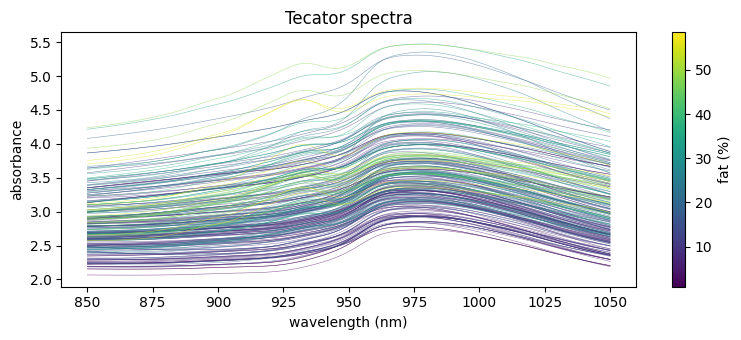

In [2]:
# the spectra, coloured by their fat value (viridis, as always)
fig, ax = plt.subplots(figsize=(8, 3.5))
order = np.argsort(y)
colors = plt.cm.viridis((y[order] - y.min()) / np.ptp(y))
for xi, c in zip(X[order, 0], colors):
    ax.plot(wavelength, xi, color=c, lw=0.4, alpha=0.6)
sm = plt.cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(y.min(), y.max()))
fig.colorbar(sm, ax=ax, label="fat (%)")
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("absorbance")
ax.set_title("Tecator spectra")
plt.tight_layout()

## Stability selection

`segment=5` makes 20 candidate bands of 10 nm each. `target_coverage`
asks for the frequency threshold whose retained fraction is NEAREST four
bands; on this spectrum seven bands tie at frequency 1.0, so seven is the
closest achievable operating point and that is what the report shows
(coverage targeting picks points on the measured frequency map, it never
splits a tie arbitrarily).

In [3]:
from robustsignalmaker import BootstrapMaskSelector

sel = BootstrapMaskSelector(task="regression", segment=5, lam=0.08,
                            n_bootstrap=50, target_coverage=4 / 20,
                            seed=0).fit(X, y)
print("selected segments:", sel.selected_segments_)
print("selected wavelengths:",
      wavelength[sel.selected_points()].min(), "to",
      wavelength[sel.selected_points()].max(), "nm (per band)")
sel.stability_report()

selected segments: [0 1 2 3 6 7 8]
selected wavelengths: 850.0 to 938.8888888888889 nm (per band)


{'n_fits': 50,
 'n_failed_fits': 0,
 'tau': 1.0,
 'coverage': 0.35,
 'assessable_universe': 20,
 'n_segments': 20,
 'unassessable_fraction': 0.0,
 'insufficient_evidence': [],
 'pi_mean': 0.6880000000000001,
 'pi_max': 1.0,
 'frac_confident_in': 0.5,
 'frac_confident_out': 0.1,
 'ambiguous_fraction': 0.4,
 'mean_obs_frac': 1.0,
 'strata': 'unstratified (regression, no observation groups)',
 'degenerate': False}

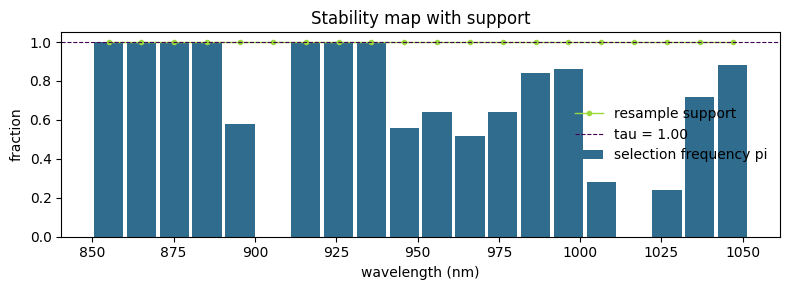

In [4]:
# pi with its mandatory co-report: never read one without the other
fig, ax = plt.subplots(figsize=(8, 3))
centres = wavelength[::5] + 5
ax.bar(centres, sel.pi_, width=9, color=plt.cm.viridis(0.35),
       label="selection frequency pi")
ax.plot(centres, sel.support_, color=plt.cm.viridis(0.85), marker="o",
        ms=3, lw=1, label="resample support")
ax.axhline(sel.tau_, color=plt.cm.viridis(0.0), lw=0.8, ls="--",
           label=f"tau = {sel.tau_:.2f}")
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("fraction")
ax.legend(frameon=False)
ax.set_title("Stability map with support")
plt.tight_layout()

## Choosing the sparsity strength with the frontier

Never trust a single lam: the frontier shows coverage, stability and
ambiguity together, and the operating point is chosen with the trade-offs
visible (the M4 note: the frequency map's ordering is robust, a fixed
threshold at a weak lam is not).

In [5]:
from robustsignalmaker import lam_frontier

rows = lam_frontier(
    lambda lam: BootstrapMaskSelector(task="regression", segment=5, lam=lam,
                                      n_bootstrap=25, seed=0).fit(X, y),
    lams=[0.02, 0.05, 0.1, 0.2])
for r in rows:
    print(r)

{'lam': 0.02, 'coverage': 0.95, 'stability_adjusted': 0.5089823406123833, 'ambiguous_fraction': 0.05, 'unassessable_fraction': 0.0, 'n_selected': 19, 'n_failed_fits': 0, 'degenerate': False}
{'lam': 0.05, 'coverage': 0.8, 'stability_adjusted': 0.43779201459597394, 'ambiguous_fraction': 0.15, 'unassessable_fraction': 0.0, 'n_selected': 16, 'n_failed_fits': 0, 'degenerate': False}
{'lam': 0.1, 'coverage': 0.45, 'stability_adjusted': 0.4469180177309953, 'ambiguous_fraction': 0.4, 'unassessable_fraction': 0.0, 'n_selected': 9, 'n_failed_fits': 0, 'degenerate': False}
{'lam': 0.2, 'coverage': 0.35, 'stability_adjusted': 0.6649040717365652, 'ambiguous_fraction': 0.15, 'unassessable_fraction': 0.0, 'n_selected': 7, 'n_failed_fits': 0, 'degenerate': False}


## The honest generalisation estimate

Nested CV fits everything per training fold and compares the selected
bands against the same head using the full spectrum. `preserved` is the
success criterion, and it means nothing SIGNIFICANT was lost: on this
dataset the full spectrum is ahead on the point estimate (RMSE 4.17 against
5.05 for the seven selected bands of twenty), and the paired test does not resolve that
difference at five folds. Read the verdict with the two means beside it.

In [6]:
from robustsignalmaker import NestedCV

res = NestedCV(k_outer=5, segment=5, lam=0.08, n_bootstrap=25,
               target_coverage=4 / 20, random_state=0).run(X, y)
summary = res.summary()
{k: summary[k] for k in ("score_name", "score_mean", "score_sd", "verdict",
                          "baseline_score_mean", "selection_stability_adjusted",
                          "mean_n_selected", "missingness_informative")}

{'score_name': 'RMSE',
 'score_mean': 5.047111206727779,
 'score_sd': 0.634315413964767,
 'verdict': 'preserved',
 'baseline_score_mean': 4.169734419762429,
 'selection_stability_adjusted': 1.0,
 'mean_n_selected': 7.0,
 'missingness_informative': False}

In [7]:
res.save("tecator_rsm_results", prefix="tecator")
sorted(__import__("os").listdir("tecator_rsm_results"))

['tecator_folds.csv',
 'tecator_mnar_guard.csv',
 'tecator_overview.csv',
 'tecator_result.pkl',
 'tecator_selected_segments.csv',
 'tecator_summary.json']

## Reading it

The selected bands sit where the CH-stretch overtone structure lives, the
verdict against the full spectrum is the claim to report, and the stability
and support numbers say how reproducible the band set is under resampling.
What to publish, and the exact phrasing template, is section 11 of
docs/INTERPRETATION_GUIDE.md.